In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
print(df.isnull().sum())

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [6]:
df = df.drop(columns=["id", "Unnamed: 32"])

print(df.shape)
df.head()

(569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
X = df.drop("diagnosis", axis=1)

y = df["diagnosis"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (569, 30)
Target: (569,)


In [8]:
y = y.map({
    "B": 0,
    "M": 1
})

print(y.value_counts())

diagnosis
0    357
1    212
Name: count, dtype: int64


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (455, 30)
Testing data: (114, 30)


In [10]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [11]:
decision_tree = DecisionTreeClassifier(
    random_state=42
)

decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [12]:
y_pred_tree = decision_tree.predict(X_test)

print(y_pred_tree[:20])

[0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0]


In [13]:
accuracy_tree = accuracy_score(y_test, y_pred_tree)

precision_tree = precision_score(
    y_test,
    y_pred_tree
)

recall_tree = recall_score(
    y_test,
    y_pred_tree
)

f1_tree = f1_score(
    y_test,
    y_pred_tree
)

print("Decision Tree")
print("-------------------")
print("Accuracy :", accuracy_tree)
print("Precision:", precision_tree)
print("Recall   :", recall_tree)
print("F1 Score :", f1_tree)

Decision Tree
-------------------
Accuracy : 0.9298245614035088
Precision: 0.9047619047619048
Recall   : 0.9047619047619048
F1 Score : 0.9047619047619048


In [14]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.94      0.94      0.94        72
   Malignant       0.90      0.90      0.90        42

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [15]:
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, n_jobs=-1, random_state=42)

In [16]:
y_pred_bagging = bagging_model.predict(X_test)

print(y_pred_bagging[:20])

[0 1 0 1 0 0 1 0 0 0 1 0 1 0 0 0 0 0 0 0]


In [17]:
accuracy_bagging = accuracy_score(
    y_test,
    y_pred_bagging
)

precision_bagging = precision_score(
    y_test,
    y_pred_bagging
)

recall_bagging = recall_score(
    y_test,
    y_pred_bagging
)

f1_bagging = f1_score(
    y_test,
    y_pred_bagging
)

print("Bagging Classifier")
print("-------------------")
print("Accuracy :", accuracy_bagging)
print("Precision:", precision_bagging)
print("Recall   :", recall_bagging)
print("F1 Score :", f1_bagging)

Bagging Classifier
-------------------
Accuracy : 0.9736842105263158
Precision: 1.0
Recall   : 0.9285714285714286
F1 Score : 0.9629629629629629


In [18]:
print(
    classification_report(
        y_test,
        y_pred_bagging,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



In [19]:
pasting_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    max_samples=1.0,
    bootstrap=False,
    random_state=42,
    n_jobs=-1
)

pasting_model.fit(X_train, y_train)

BaggingClassifier(bootstrap=False,
                  estimator=DecisionTreeClassifier(random_state=42),
                  n_estimators=100, n_jobs=-1, random_state=42)

In [20]:
y_pred_pasting = pasting_model.predict(X_test)

print(y_pred_pasting[:20])

[0 1 1 1 0 0 1 0 0 0 1 0 1 0 0 0 1 0 0 0]


In [21]:
accuracy_pasting = accuracy_score(
    y_test,
    y_pred_pasting
)

precision_pasting = precision_score(
    y_test,
    y_pred_pasting
)

recall_pasting = recall_score(
    y_test,
    y_pred_pasting
)

f1_pasting = f1_score(
    y_test,
    y_pred_pasting
)

print("Pasting Classifier")
print("-------------------")
print("Accuracy :", accuracy_pasting)
print("Precision:", precision_pasting)
print("Recall   :", recall_pasting)
print("F1 Score :", f1_pasting)

Pasting Classifier
-------------------
Accuracy : 0.9298245614035088
Precision: 0.925
Recall   : 0.8809523809523809
F1 Score : 0.9024390243902439


In [22]:
print(
    classification_report(
        y_test,
        y_pred_pasting,
        target_names=["Benign", "Malignant"]
    )
)

              precision    recall  f1-score   support

      Benign       0.93      0.96      0.95        72
   Malignant       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



In [23]:
results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Bagging",
        "Pasting"
    ],

    "Accuracy": [
        accuracy_tree,
        accuracy_bagging,
        accuracy_pasting
    ],

    "Precision": [
        precision_tree,
        precision_bagging,
        precision_pasting
    ],

    "Recall": [
        recall_tree,
        recall_bagging,
        recall_pasting
    ],

    "F1 Score": [
        f1_tree,
        f1_bagging,
        f1_pasting
    ]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.929825,0.904762,0.904762,0.904762
1,Bagging,0.973684,1.000000,0.928571,0.962963
2,Pasting,0.929825,0.925000,0.880952,0.902439


In [24]:
results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.9298,0.9048,0.9048,0.9048
1,Bagging,0.9737,1.0000,0.9286,0.9630
2,Pasting,0.9298,0.9250,0.8810,0.9024


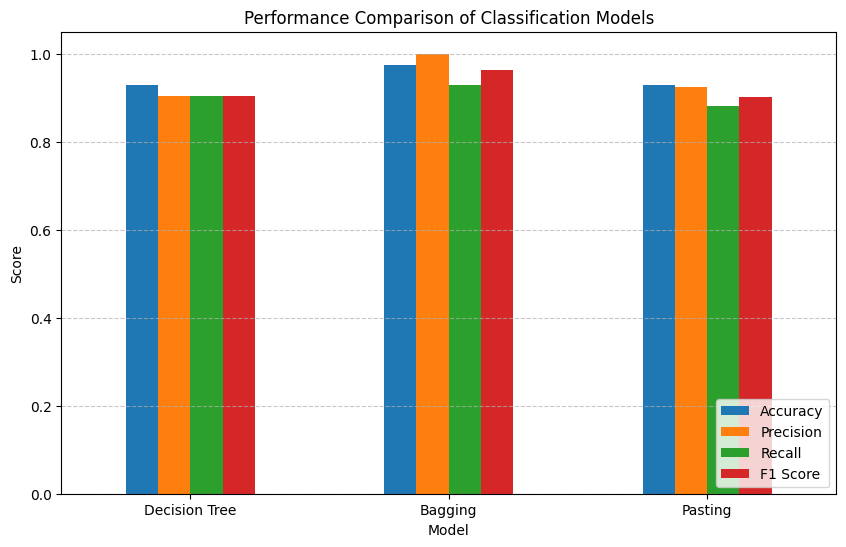

In [25]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Classification Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)

plt.xticks(rotation=0)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.legend(loc="lower right")

plt.show()

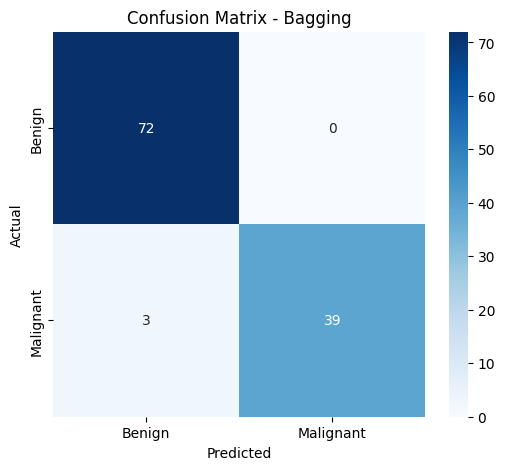

In [26]:
cm = confusion_matrix(
    y_test,
    y_pred_bagging
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Bagging")

plt.show()

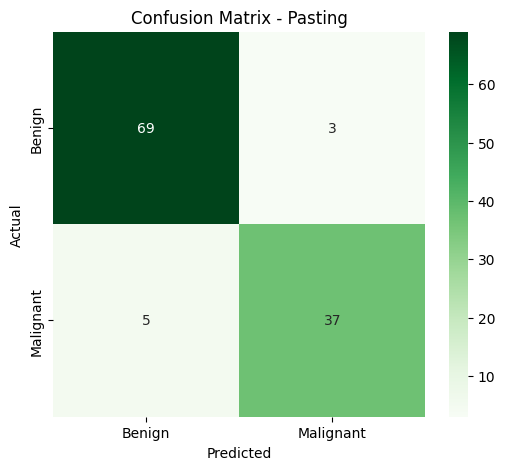

In [27]:
cm = confusion_matrix(
    y_test,
    y_pred_pasting
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Pasting")

plt.show()

In [28]:
print("FINAL MODEL COMPARISON")
print("=" * 60)

for _, row in results.iterrows():
    print(f"\n{row['Model']}")
    print("-" * 30)
    print(f"Accuracy : {row['Accuracy']:.4f}")
    print(f"Precision: {row['Precision']:.4f}")
    print(f"Recall   : {row['Recall']:.4f}")
    print(f"F1 Score : {row['F1 Score']:.4f}")

FINAL MODEL COMPARISON

Decision Tree
------------------------------
Accuracy : 0.9298
Precision: 0.9048
Recall   : 0.9048
F1 Score : 0.9048

Bagging
------------------------------
Accuracy : 0.9737
Precision: 1.0000
Recall   : 0.9286
F1 Score : 0.9630

Pasting
------------------------------
Accuracy : 0.9298
Precision: 0.9250
Recall   : 0.8810
F1 Score : 0.9024


In [29]:
results.to_csv(
    "model_performance_comparison.csv",
    index=False
)

print("Performance table saved successfully.")

Performance table saved successfully.
